<a href="https://colab.research.google.com/github/Kashishkewat/python_practice/blob/main/day24_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Polynomial Regression**

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import make_pipeline

In [75]:
X=6*np.random.rand(200,1)-3
y=0.8 *X**2 +0.9*X +2 +np.random.randn(200,1)
#y=0.8x^2+0.9x+2

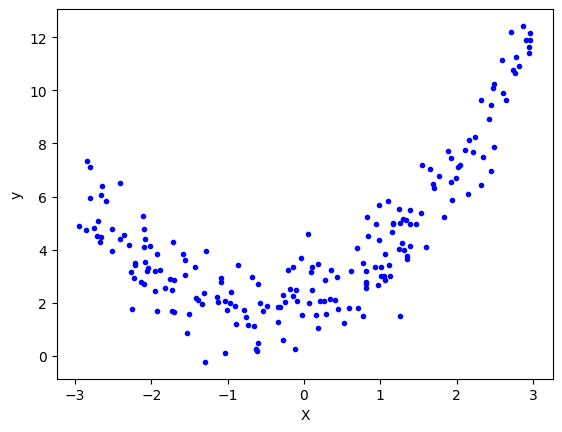

In [76]:
plt.plot(X,y,"b. ")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [77]:
#train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)
#

In [78]:
#applying linear regression
lr=LinearRegression()

In [79]:
lr.fit(X_train,y_train)

LinearRegression()

In [80]:
y_pred=lr.predict(X_test)

In [81]:
r2_score(y_test,y_pred)

0.39050753276941874

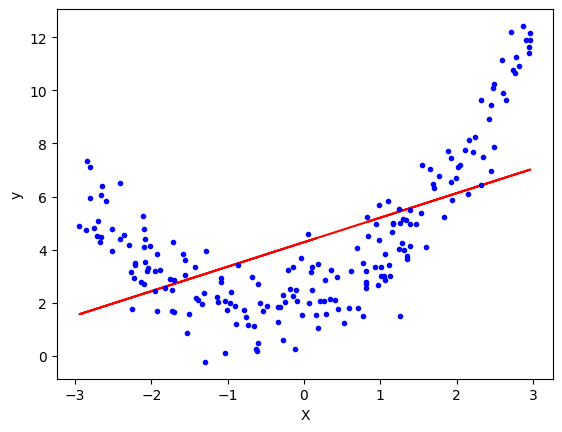

In [82]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X,y,"b. ")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [83]:
#apply polynomial  linear regression degree2
ploy=PolynomialFeatures(degree=5)
X_train_trans=ploy.fit_transform(X_train)
X_test_trans=ploy.transform(X_test)

In [84]:
print(X_train[0])
print(X_train_trans[0])

[0.84060163]
[1.         0.84060163 0.70661111 0.59397845 0.49929925 0.41971177]


In [85]:
lr=LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [86]:
y_pred=lr.predict(X_test_trans)

In [87]:
r2_score(y_test,y_pred)

0.8712262926905915

In [88]:
lr.coef_

array([[ 0.        ,  0.93271736,  0.76335086, -0.02058816,  0.00483809,
         0.00340144]])

In [89]:
lr.intercept_

array([2.06997894])

In [90]:
X_new=np.linspace(-3,3,100).reshape(100,1)
X_new_trans=ploy.transform(X_new)
y_new=lr.predict(X_new_trans)

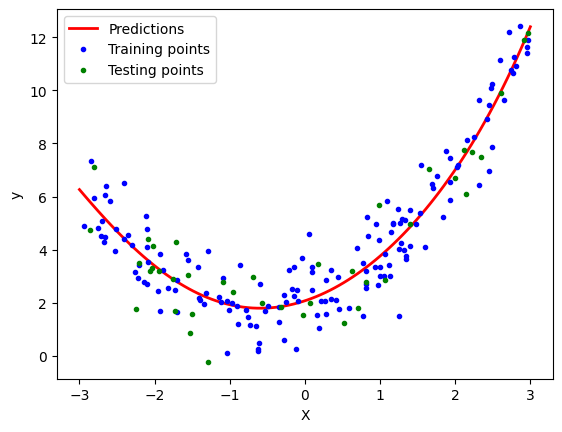

In [91]:
plt.plot(X_new,y_new,'r-',linewidth=2,label='Predictions')
plt.plot(X_train,y_train,'b.',label='Training points')
plt.plot(X_test,y_test,"g. ",label='Testing points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [92]:
#3D polynomial regression
x=7*np.random.rand(150,1)-2.8
y=7*np.random.rand(150,1)-2.8
z=x**2 + y**2 +0.2*x+0.2*y+0.1*x*y+2+np.random.randn(150,1)
#z=x^2+y^2+0.2x+0.2y+0.1xy+2

In [93]:
import plotly.express as px
df=px.data.iris()
fig=px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.show()

# **Mini Project Python**

## **House price predictor**

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [95]:
data = {
    "Area": [800, 1000, 1200, 1500, 1800, 2000],
    "Bedrooms": [1, 2, 2, 3, 3, 4],
    "Bathrooms": [1, 1, 2, 2, 3, 3],
    "Price": [40, 50, 60, 80, 100, 120]  # price in lakhs
}

df = pd.DataFrame(data)
df


,Area,Bedrooms,Bathrooms,Price
0,800,1,1,40
1,1000,2,1,50
2,1200,2,2,60
3,1500,3,2,80
4,1800,3,3,100
5,2000,4,3,120


In [101]:
X3 = df[["Area", "Bedrooms", "Bathrooms"]]  # Features
y3 = df["Price"]                            # Target


In [102]:
X_train, X_test, y_train, y_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

In [113]:
lr3=LinearRegression()
lr3.fit(X_train,y_train)

LinearRegression()

In [114]:
y_pred=lr3.predict(X_test)
print(y_pred)

[20. 40.]


In [115]:
lr3.coef_

array([2.86235668e-15, 2.00000000e+01, 2.00000000e+01])

In [116]:
lr3.intercept_

np.float64(-20.000000000004746)

In [107]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 15.000000000002121
MSE: 250.00000000006656
RMSE: 15.811388300844001
R2 Score: -9.000000000002663


In [123]:
new_house = [[1400, 4,3]]
predicted_price = lr3.predict(new_house)

print("Predicted House Price (in lakhs):", predicted_price[0])


Predicted House Price (in lakhs): 119.9999999999994


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

